# 无监督学习 - 聚类

https://www.runoob.com/ml/ml-cluster-analysis.html

在机器学习中，聚类 要做的正是这样的事情。它是一种无监督学习方法，目标是在没有预先标注答案（即没有"标签"）的数据中，发现其内在的结构和分组。

## 什么是无监督学习与聚类？

在开始之前，我们先快速区分一下机器学习的两大范式：

- 监督学习：就像有老师指导的学习。我们给算法提供大量问题（特征数据）和对应的标准答案（标签），让它学习从问题到答案的映射关系。例如，给算法看很多猫和狗的图片（特征），并告诉它每张图是猫还是狗（标签），训练后它就能识别新的图片。

- 无监督学习：就像让机器自己去探索和发现。我们只提供问题（特征数据），不提供答案（标签）。算法的任务是自行从数据中找出模式、结构或关系。聚类就是其中最核心的技术之一。

聚类的核心思想：将数据集中的样本划分成若干个互不相交的子集（称为簇或类），使得同一个簇内的样本彼此相似，而不同簇中的样本彼此不相似。

这里的相似通常通过数学上的距离来衡量（如欧氏距离）。

距离越近，相似度越高。

## 经典聚类算法：K-Means

K-Means 是最著名、最常用的聚类算法之一，其思想直观，实现相对简单。

- 确定簇的数量 K：首先，你需要决定想把数据分成几类。这个 K 值需要预先指定，这是 K-Means 的一个关键参数。
- 初始化代表（质心）：随机在数据空间中选取 K 个点，作为每个簇的初始"中心点"，我们称之为质心。
- 分配居民（样本）：计算数据集中每一个样本点到这 K 个质心的距离。遵循"近者归其类"的原则，将每个样本分配给距离它最近的那个质心所在的簇。这样，所有样本就被划分到了 K 个簇中。
改选新代表更新质心）：现在，每个簇里都有了一批样本。重新计算每个簇的质心，新的质心就是该簇内所有样本点的平均值（均值点）。
- 重复与收敛：重复步骤 3（分配）和步骤 4（更新），直到质心的位置不再发生显著变化（即算法收敛）。此时，每个样本的所属簇也不再变化。

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [3]:
# 1. 创建一个人工数据集
# 我们生成 300 个样本点，它们天然地围绕 4 个中心分布（方便我们观察）
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
# X 是特征数据，y_true 是真实的类别标签（仅用于最后对比，聚类算法不会用到它）

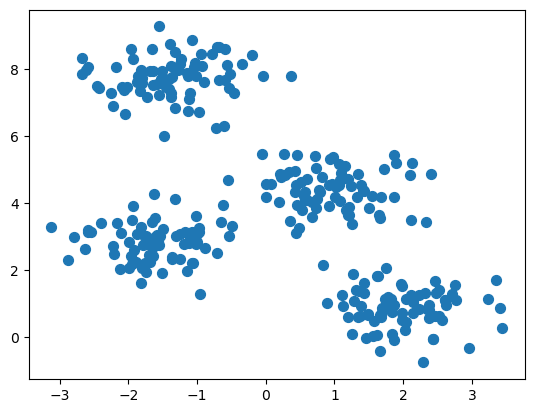

In [5]:
# 2. 可视化原始数据
plt.scatter(X[:, 0], X[:, 1], s=50) # s 是点的大小
plt.show()

In [6]:
kmeans = KMeans(n_clusters=4, random_state=0, n_init='auto')

In [10]:
y_kmeans = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_
y_kmeans

array([1, 2, 0, 2, 1, 1, 3, 0, 2, 2, 3, 2, 0, 2, 1, 0, 0, 1, 3, 3, 1, 1,
       0, 3, 3, 0, 1, 0, 3, 0, 2, 2, 0, 2, 2, 2, 2, 2, 3, 1, 0, 3, 0, 0,
       3, 3, 2, 3, 2, 1, 3, 1, 2, 1, 1, 3, 2, 3, 2, 1, 2, 0, 2, 3, 3, 3,
       2, 1, 2, 3, 0, 3, 2, 3, 3, 2, 3, 0, 1, 2, 1, 0, 1, 1, 2, 0, 1, 0,
       2, 2, 0, 1, 2, 3, 3, 0, 1, 1, 0, 3, 2, 1, 2, 1, 0, 1, 1, 0, 2, 0,
       3, 3, 1, 2, 1, 0, 2, 1, 1, 0, 3, 1, 3, 1, 1, 1, 1, 3, 1, 3, 2, 3,
       3, 1, 2, 3, 3, 2, 0, 2, 2, 3, 0, 3, 0, 3, 2, 0, 2, 2, 2, 0, 2, 0,
       1, 3, 2, 3, 1, 0, 2, 0, 0, 1, 0, 3, 3, 0, 1, 0, 0, 2, 1, 0, 3, 2,
       1, 1, 0, 3, 1, 0, 3, 3, 0, 0, 0, 0, 1, 2, 0, 3, 0, 0, 3, 3, 3, 0,
       3, 2, 0, 3, 1, 3, 0, 2, 3, 2, 0, 2, 0, 3, 0, 0, 2, 3, 3, 1, 1, 0,
       2, 1, 1, 3, 1, 3, 0, 2, 2, 0, 0, 2, 0, 1, 3, 0, 1, 3, 2, 3, 1, 0,
       1, 2, 2, 2, 2, 3, 3, 2, 0, 3, 1, 0, 3, 3, 3, 1, 1, 2, 0, 0, 3, 1,
       2, 3, 0, 2, 0, 1, 1, 3, 3, 0, 1, 1, 1, 0, 2, 2, 1, 1, 0, 1, 1, 1,
       2, 3, 2, 0, 1, 1, 2, 2, 2, 1, 1, 0, 2, 3], d

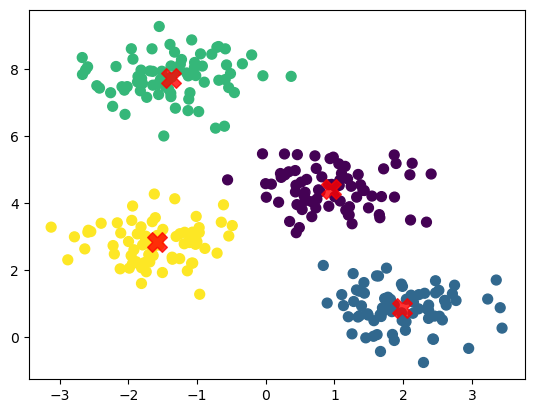

前10个样本的簇标签: [1 2 0 2 1 1 3 0 2 2]
四个簇的质心坐标:
 [[ 0.94973532  4.41906906]
 [ 1.98258281  0.86771314]
 [-1.37324398  7.75368871]
 [-1.58438467  2.83081263]]


In [12]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, alpha=0.8, marker='X')
plt.show()

# 打印前10个样本的预测簇标签
print("前10个样本的簇标签:", y_kmeans[:10])
# 打印质心坐标
print("四个簇的质心坐标:\n", centroids)

代码解析：

- make_blobs：生成用于聚类的模拟数据集，centers=4 表示数据围绕 4 个中心点生成。
- KMeans(n_clusters=4)：创建 K-Means 模型实例，指定簇数 K 为 4。n_init='auto' 是运行算法的次数，取最佳结果。
- fit_predict(X)：核心方法，在数据 X 上拟合模型并返回每个样本的簇索引（0, 1, 2, 3）。
- cluster_centers_：属性，存储训练后得到的 K 个质心的坐标。


## 如何选择最佳的 K 值？

在上面的例子中，因为我们知道数据是围绕 4 个中心生成的，所以轻松地设置了 K=4。但在现实世界中，我们往往不知道数据应该分成几类。如何选择 K 呢？

一个常用的方法是 "肘部法则"。其思想是：随着簇数量 K 的增加，样本点到其所属簇质心的平均距离（称为畸变程度或 inertia）会下降。当 K 小于真实簇数时，增加 K 会大幅降低这个距离；当 K 达到真实簇数后，再增加 K，距离的下降幅度会骤减。这个拐点就像手肘的关节，对应的 K 值就是较好的选择。

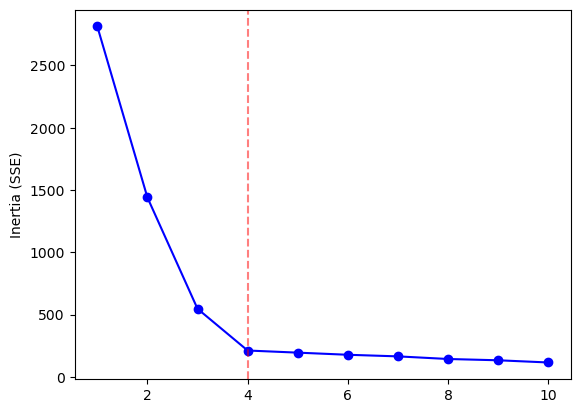

In [13]:
# 肘部法则示例：计算不同K值下的 inertia
inertias = []
K_range = range(1, 11) # 测试 K 从 1 到 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_) # inertia_ 属性即 SSE

# 绘制肘部曲线
plt.plot(K_range, inertias, 'bo-')
plt.ylabel('Inertia (SSE)')
plt.axvline(x=4, color='r', linestyle='--', alpha=0.5) # 标记我们已知的 K=4
plt.show()

## 聚类的应用场景

聚类是一种强大的探索性数据分析工具，应用极其广泛：

- 客户细分：在电商或营销中，根据客户的购买行为、 demographics（人口统计特征）进行聚类，划分出"高价值客户"、"价格敏感客户"等群体，以便实施精准营销。
- 图像分割：将图像中的像素根据颜色、纹理进行聚类，可以用于简化图像、识别前景和背景。
- 异常检测：正常的数据点通常会形成密集的簇，而异常点则远离任何簇的中心。通过聚类可以发现这些离群点。
- 文档归类：对新闻文章或研究论文进行聚类，自动发现热点话题或研究领域。
- 社交网络分析：在社交网络中，通过对用户的关系、互动进行聚类，可以发现社区或圈子。